# 🔧 Étape 2 — Préprocessing

Maintenant que l'EDA est faite, on prépare les données pour les modèles.  
Cette étape couvre :

1. **Nettoyage** : suppression des colonnes vides, imputation des rares NaN
2. **Rééchantillonnage** : vérification de la régularité temporelle (1 ligne = 1 minute)
3. **Sélection de features** : garder les variables utiles selon le guide projet
4. **Création des lags** : décaler les variables dans le temps pour le forecasting
5. **Normalisation** : mise à l'échelle pour les modèles ML/DL
6. **Split train/test** : découpe temporelle (pas de shuffle !)
7. **Sauvegarde** : export des datasets prêts à l'emploi

> **Horizon de prédiction choisi : 10 minutes** (recommandé dans le guide projet)  
> Cela signifie qu'on cherche à prédire `1_LT_001_PV` à t+10 à partir des données jusqu'à t.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# Paramètres globaux — modifier ici pour changer l'horizon
TARGET      = '1_LT_001_PV'
HORIZON     = 10          # minutes dans le futur à prédire
N_LAGS      = 30          # nombre de pas de temps passés à inclure comme features
TEST_RATIO  = 0.2         # 20% des données pour le test
RANDOM_SEED = 42

print(f"Horizon de prédiction : {HORIZON} min")
print(f"Nombre de lags        : {N_LAGS} min")
print(f"Ratio test            : {TEST_RATIO*100:.0f}%")

Horizon de prédiction : 10 min
Nombre de lags        : 30 min
Ratio test            : 20%


## 2. Chargement (identique à l'EDA)

On recharge les données brutes et on reconstruit l'index temporel.

In [2]:
df_raw = pd.read_csv('WADI_14days_new.csv')

df_raw['datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'], dayfirst=False, errors='coerce')
df_raw = df_raw.sort_values('datetime').reset_index(drop=True)
df_raw = df_raw.set_index('datetime')
df_raw = df_raw.drop(columns=['Row', 'Date', 'Time'], errors='ignore')

for col in df_raw.columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Shape brut : {df_raw.shape}")
print(f"Période    : {df_raw.index.min()} → {df_raw.index.max()}")

Shape brut : (784571, 127)
Période    : 2017-09-25 00:00:00 → 2017-09-29 23:00:59


## 3. Nettoyage

### 3a. Suppression des colonnes entièrement vides

L'EDA a révélé 4 colonnes à 100% NaN (`2_P_001_STATUS`, `2_P_002_STATUS`, `2_LS_001_AL`, `2_LS_002_AL`).  
Ces colonnes ne contiennent aucune information — on les supprime.

**Résultat attendu :** confirmation des colonnes supprimées.

In [3]:
# Colonnes 100% vides
empty_cols = df_raw.columns[df_raw.isnull().mean() == 1.0].tolist()
print(f"Colonnes supprimées ({len(empty_cols)}) : {empty_cols}")

df = df_raw.drop(columns=empty_cols)
print(f"Shape après suppression : {df.shape}")

Colonnes supprimées (4) : ['2_LS_001_AL', '2_LS_002_AL', '2_P_001_STATUS', '2_P_002_STATUS']
Shape après suppression : (784571, 123)


### 3b. Imputation des NaN résiduels

Pour les colonnes avec très peu de NaN (< 1%), on utilise une **interpolation linéaire** suivie d'un **forward-fill** pour les éventuels NaN en début de série.  
Cette méthode est adaptée aux séries temporelles continues.

**Résultat attendu :** 0 NaN restant dans le dataset.

In [4]:
nan_before = df.isnull().sum().sum()
print(f"NaN avant imputation : {nan_before}")

# Interpolation linéaire (adaptée aux séries temporelles)
df = df.interpolate(method='linear', limit_direction='both')
# Forward-fill pour les éventuels NaN résiduels en début/fin
df = df.ffill().bfill()

nan_after = df.isnull().sum().sum()
print(f"NaN après imputation  : {nan_after}")
assert nan_after == 0, "Il reste des NaN — vérifier les données !"

NaN avant imputation : 34
NaN après imputation  : 0


## 4. Régularité temporelle

Le dataset est censé être à **1 mesure par minute**. On vérifie qu'il n'y a pas de trous ou de doublons dans l'index.  
Si des minutes sont manquantes, on les insère et on interpole pour garder une série régulière.

**Résultat attendu :** index 100% régulier à 1 min, 0 trou.

In [5]:
# Calcul des intervalles entre mesures consécutives
diffs = df.index.to_series().diff().dropna()
print("Distribution des intervalles temporels :")
print(diffs.value_counts().head(10))

# Rééchantillonnage à 1 minute pour garantir la régularité
df = df.resample('1min').mean()
df = df.interpolate(method='linear', limit_direction='both')

print(f"\nShape après resample : {df.shape}")
print(f"NaN après resample   : {df.isnull().sum().sum()}")

# Vérification finale
gaps = df.index.to_series().diff().dropna()
n_gaps = (gaps != pd.Timedelta('1min')).sum()
print(f"Trous résiduels      : {n_gaps}")

Distribution des intervalles temporels :
datetime
0 days 00:00:00    127919
0 days 00:00:01      7080
0 days 00:59:01       119
Name: count, dtype: int64

Shape après resample : (7141, 123)
NaN après resample   : 0
Trous résiduels      : 0


## 5. Sélection de features

On ne garde que les variables pertinentes pour prédire le niveau du réservoir.  
Le choix est guidé par :
- Le **guide projet** (débits FIT, pompes, vannes, controllers FIC)
- L'**analyse de corrélation** de l'EDA
- Le **sens physique** : ce qui entre/sort du réservoir influence son niveau

On exclut les colonnes redondantes (FQ = intégrales des FIT), les alarmes purement contextuelles, et les capteurs sans lien physique clair.

**Résultat attendu :** liste des features retenues.

In [6]:
# Features sélectionnées selon le guide projet + EDA
FEATURES = [
    # Débits entrant/sortant (FIT)
    '1_FIT_001_PV',
    '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV',
    '3_FIT_001_PV',

    # Vannes (MV)
    '1_MV_001_STATUS', '1_MV_003_STATUS', '1_MV_004_STATUS',
    '2_MV_001_STATUS', '2_MV_002_STATUS',
    '3_MV_001_STATUS', '3_MV_002_STATUS',

    # Pompes
    '1_P_001_STATUS', '1_P_002_STATUS',
    '2_P_003_STATUS', '2_P_003_SPEED',
    '2_P_004_STATUS', '2_P_004_SPEED',
    '3_P_001_STATUS', '3_P_002_STATUS',

    # Controllers FIC
    '2_FIC_101_SP', '2_FIC_101_PV', '2_FIC_101_CO',
    '2_FIC_201_SP', '2_FIC_201_PV', '2_FIC_201_CO',
    '2_FIC_301_SP', '2_FIC_301_PV', '2_FIC_301_CO',

    # Niveaux connexes
    '2_LT_001_PV', '2_LT_002_PV', '3_LT_001_PV',

    # Pression
    '2_PIT_001_PV', '2_PIT_002_PV',

    # Consommation totale requise
    'TOTAL_CONS_REQUIRED_FLOW',
]

# Garder uniquement les colonnes présentes dans le dataset
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features retenues : {len(FEATURES)}")
for f in FEATURES:
    print(f"  {f}")

Features retenues : 35
  1_FIT_001_PV
  2_FIT_001_PV
  2_FIT_002_PV
  2_FIT_003_PV
  3_FIT_001_PV
  1_MV_001_STATUS
  1_MV_003_STATUS
  1_MV_004_STATUS
  2_MV_001_STATUS
  2_MV_002_STATUS
  3_MV_001_STATUS
  3_MV_002_STATUS
  1_P_001_STATUS
  1_P_002_STATUS
  2_P_003_STATUS
  2_P_003_SPEED
  2_P_004_STATUS
  2_P_004_SPEED
  3_P_001_STATUS
  3_P_002_STATUS
  2_FIC_101_SP
  2_FIC_101_PV
  2_FIC_101_CO
  2_FIC_201_SP
  2_FIC_201_PV
  2_FIC_201_CO
  2_FIC_301_SP
  2_FIC_301_PV
  2_FIC_301_CO
  2_LT_001_PV
  2_LT_002_PV
  3_LT_001_PV
  2_PIT_001_PV
  2_PIT_002_PV
  TOTAL_CONS_REQUIRED_FLOW


In [7]:
# On construit le dataframe de travail avec target + features
df_work = df[[TARGET] + FEATURES].copy()
print(f"Shape df_work : {df_work.shape}")
df_work.head(3)

Shape df_work : (7141, 36)


,1_LT_001_PV,1_FIT_001_PV,2_FIT_001_PV,2_FIT_002_PV,2_FIT_003_PV,3_FIT_001_PV,1_MV_001_STATUS,1_MV_003_STATUS,1_MV_004_STATUS,2_MV_001_STATUS,...,2_FIC_201_CO,2_FIC_301_SP,2_FIC_301_PV,2_FIC_301_CO,2_LT_001_PV,2_LT_002_PV,3_LT_001_PV,2_PIT_001_PV,2_PIT_002_PV,TOTAL_CONS_REQUIRED_FLOW
datetime,,,,,,,,,,,,,,,,,,,,,
2017-09-25 00:00:00,57.164868,0.318850,0.365335,0.275679,0.021903,0.456084,1.166667,1.0,1.5,1.0,...,50.867075,0.108333,0.066718,51.432408,69.890390,74.714899,64.959929,153.004358,91.823164,0.412333
2017-09-25 00:01:00,57.163400,0.318847,0.365563,0.275570,0.022449,0.456022,1.166667,1.0,1.5,1.0,...,50.911481,0.108333,0.066599,51.478379,69.890666,74.710719,64.960185,153.000213,91.801839,0.412267
2017-09-25 00:02:00,57.161933,0.318845,0.365790,0.275461,0.022994,0.455961,1.166667,1.0,1.5,1.0,...,50.955887,0.108333,0.066480,51.524350,69.890942,74.706539,64.960441,152.996068,91.780514,0.412200


## 6. Création de la variable cible décalée

Pour prédire le niveau **dans 10 minutes**, on crée une colonne `target` = `1_LT_001_PV` décalée de -10 lignes.  
Les dernières lignes (sans futur connu) sont supprimées.

**Résultat attendu :** colonne `target` alignée avec les features à t, représentant la valeur à t+10.

Shape après création target : (7131, 37)
Lignes supprimées (fin)     : 10


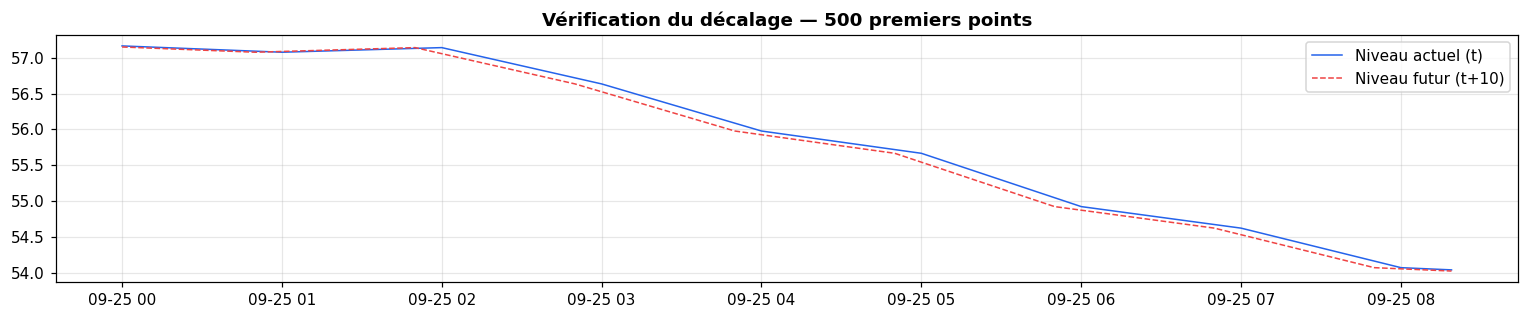

In [8]:
# Décalage de la cible : on veut prédire le niveau dans HORIZON minutes
df_work['target'] = df_work[TARGET].shift(-HORIZON)

# Suppression des lignes sans futur (fin de série)
df_work = df_work.dropna(subset=['target'])

print(f"Shape après création target : {df_work.shape}")
print(f"Lignes supprimées (fin)     : {HORIZON}")

# Vérification visuelle : target doit être en avance sur 1_LT_001_PV
fig, ax = plt.subplots(figsize=(14, 3))
sample = df_work.iloc[:500]
ax.plot(sample.index, sample[TARGET], label='Niveau actuel (t)', color='#2563EB', linewidth=1)
ax.plot(sample.index, sample['target'], label=f'Niveau futur (t+{HORIZON})', color='#EF4444',
        linewidth=1, linestyle='--')
ax.set_title(f'Vérification du décalage — 500 premiers points', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Création des features laggées

Les modèles ML (XGBoost, Random Forest) ne prennent pas de séquences en entrée — ils ont besoin de **colonnes**.  
On crée donc des lags : pour chaque variable, on ajoute ses valeurs à t-1, t-2, ..., t-N_LAGS comme nouvelles colonnes.

Cela encode l'historique récent sous forme tabulaire, ce que les arbres de décision peuvent exploiter.

> Note : pour les modèles LSTM/GRU, on n'utilisera **pas** ces lags — on reformatera les données en séquences 3D directement.

**Résultat attendu :** dataframe élargi avec toutes les colonnes laggées.

In [9]:
def add_lags(df, columns, n_lags):
    """Ajoute les valeurs décalées (lags) pour les colonnes spécifiées."""
    df_lag = df.copy()
    for col in columns:
        for lag in range(1, n_lags + 1):
            df_lag[f'{col}_lag{lag}'] = df_lag[col].shift(lag)
    return df_lag

# Colonnes pour lesquelles on crée des lags
# On lag la cible + les débits et statuts les plus importants
LAG_COLS = [TARGET] + [
    '1_FIT_001_PV', '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV',
    '1_MV_001_STATUS', '1_MV_004_STATUS',
    '1_P_001_STATUS', '2_P_003_STATUS',
    '2_FIC_101_CO', '2_FIC_101_PV',
]
LAG_COLS = [c for c in LAG_COLS if c in df_work.columns]

print(f"Création des lags (n={N_LAGS}) pour {len(LAG_COLS)} colonnes...")
df_lagged = add_lags(df_work, LAG_COLS, N_LAGS)

# Suppression des premières lignes (sans historique complet)
df_lagged = df_lagged.dropna()

print(f"Shape avant lags : {df_work.shape}")
print(f"Shape après lags : {df_lagged.shape}")
print(f"Nouvelles colonnes ajoutées : {df_lagged.shape[1] - df_work.shape[1]}")

Création des lags (n=30) pour 11 colonnes...
Shape avant lags : (7131, 37)
Shape après lags : (7101, 367)
Nouvelles colonnes ajoutées : 330


## 8. Normalisation

On applique un **MinMaxScaler** (mise à l'échelle entre 0 et 1) sur les features continues.  
Les colonnes binaires/catégorielles (STATUS = 0/1/2) sont laissées telles quelles.

**Pourquoi normaliser ?**  
- Les débits sont en L/min, les niveaux en cm, les pressions en bar → échelles très différentes  
- Sans normalisation, les modèles à gradient (LSTM, régression) convergent mal

⚠️ Le scaler est **fitté uniquement sur le train** et appliqué au test — jamais l'inverse (data leakage).

**Résultat attendu :** toutes les features continues dans [0, 1].

## 9. Split train / test

On coupe les données en **respectant l'ordre temporel** — pas de shuffle.  
Mélanger les données créerait une fuite d'information (le modèle verrait des données futures à l'entraînement).

Répartition : **80% train / 20% test**.

**Résultat attendu :** deux datasets disjoints temporellement.

In [10]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Séparation X / y
feature_cols = [c for c in df_lagged.columns if c != 'target']
X = df_lagged[feature_cols].values
y = df_lagged['target'].values
timestamps = df_lagged.index

# Split temporel — pas de shuffle
split_idx = int(len(X) * (1 - TEST_RATIO))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
ts_train, ts_test = timestamps[:split_idx], timestamps[split_idx:]

print(f"Train : {X_train.shape[0]:,} lignes — {ts_train[0].strftime('%d/%m/%Y')} → {ts_train[-1].strftime('%d/%m/%Y')}")
print(f"Test  : {X_test.shape[0]:,} lignes — {ts_test[0].strftime('%d/%m/%Y')} → {ts_test[-1].strftime('%d/%m/%Y')}")

# Identification des colonnes continues (à normaliser)
status_keywords = ['STATUS', 'SPEED', 'START_STOP', 'LOG']
continuous_mask = np.array([
    not any(kw in col for kw in status_keywords)
    for col in feature_cols
])
print(f"\nFeatures continues (à normaliser) : {continuous_mask.sum()}")
print(f"Features discrètes (inchangées)   : {(~continuous_mask).sum()}")

# Fit du scaler sur le train uniquement
scaler_X = MinMaxScaler()
X_train[:, continuous_mask] = scaler_X.fit_transform(X_train[:, continuous_mask])
X_test[:, continuous_mask]  = scaler_X.transform(X_test[:, continuous_mask])

# Scaler pour la cible (utile pour LSTM)
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("\n✅ Normalisation OK")
print(f"  X_train features range : [{X_train[:, continuous_mask].min():.3f}, {X_train[:, continuous_mask].max():.3f}]")

Train : 5,680 lignes — 25/09/2017 → 28/09/2017
Test  : 1,421 lignes — 28/09/2017 → 29/09/2017

Features continues (à normaliser) : 231
Features discrètes (inchangées)   : 135

✅ Normalisation OK
  X_train features range : [0.000, 1.000]


## 10. Visualisation du split

On vérifie visuellement que la coupure train/test est bien temporelle et que les deux ensembles couvrent des dynamiques représentatives.

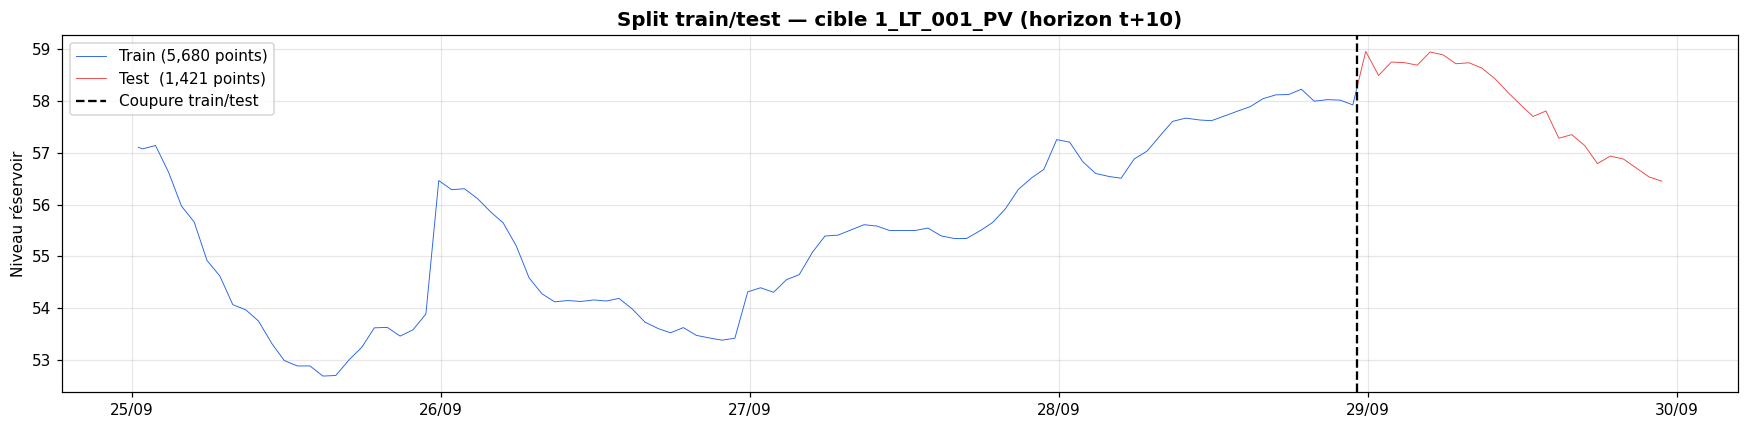

In [11]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(ts_train, y_train, color='#2563EB', linewidth=0.6, label=f'Train ({len(y_train):,} points)')
ax.plot(ts_test,  y_test,  color='#EF4444', linewidth=0.6, label=f'Test  ({len(y_test):,} points)')
ax.axvline(ts_test[0], color='black', linestyle='--', linewidth=1.5, label='Coupure train/test')

ax.set_title(f'Split train/test — cible 1_LT_001_PV (horizon t+{HORIZON})', fontsize=13, fontweight='bold')
ax.set_ylabel('Niveau réservoir')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Préparation des séquences pour LSTM/GRU

Les réseaux récurrents (LSTM, GRU) prennent en entrée des tenseurs 3D : `(samples, timesteps, features)`.  
On crée des fenêtres glissantes de taille `WINDOW_SIZE` sur les données **non laggées** (on n'a plus besoin des lags manuels, le réseau gère l'historique lui-même).

**Résultat attendu :** tableaux 3D prêts pour PyTorch/Keras.

In [12]:
WINDOW_SIZE = 30  # 30 minutes d'historique pour les séquences LSTM

def make_sequences(df_src, feature_cols_seq, target_col, window, horizon):
    """
    Crée des séquences glissantes pour les modèles récurrents.
    Retourne X_seq (N, window, n_features) et y_seq (N,).
    """
    values = df_src[feature_cols_seq].values
    targets = df_src[target_col].values

    X_seq, y_seq = [], []
    for i in range(window, len(values) - horizon + 1):
        X_seq.append(values[i - window:i])
        y_seq.append(targets[i + horizon - 1])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

# Features pour les séquences : on utilise TARGET + FEATURES (sans les lags)
seq_feature_cols = [TARGET] + FEATURES
seq_feature_cols = [c for c in seq_feature_cols if c in df_work.columns]

# Normalisation du df_work pour les séquences
df_seq = df_work[seq_feature_cols].copy()
split_seq_idx = int(len(df_seq) * (1 - TEST_RATIO))

# Fit scaler sur les colonnes continues uniquement
cont_seq_mask = np.array([not any(kw in c for kw in status_keywords) for c in seq_feature_cols])
scaler_seq = MinMaxScaler()
df_seq_vals = df_seq.values.copy().astype(float)
df_seq_vals[:split_seq_idx, cont_seq_mask] = scaler_seq.fit_transform(
    df_seq_vals[:split_seq_idx, cont_seq_mask])
df_seq_vals[split_seq_idx:, cont_seq_mask] = scaler_seq.transform(
    df_seq_vals[split_seq_idx:, cont_seq_mask])

df_seq_norm = pd.DataFrame(df_seq_vals, index=df_seq.index, columns=seq_feature_cols)

# Création des séquences
df_seq_train = df_seq_norm.iloc[:split_seq_idx]
df_seq_test  = df_seq_norm.iloc[split_seq_idx:]

X_seq_train, y_seq_train = make_sequences(df_seq_train, seq_feature_cols, TARGET, WINDOW_SIZE, HORIZON)
X_seq_test,  y_seq_test  = make_sequences(df_seq_test,  seq_feature_cols, TARGET, WINDOW_SIZE, HORIZON)

print(f"Séquences train : {X_seq_train.shape}  →  y: {y_seq_train.shape}")
print(f"Séquences test  : {X_seq_test.shape}   →  y: {y_seq_test.shape}")
print(f"\nFormat : (samples, timesteps={WINDOW_SIZE}, features={X_seq_train.shape[2]})")

Séquences train : (5665, 30, 36)  →  y: (5665,)
Séquences test  : (1388, 30, 36)   →  y: (1388,)

Format : (samples, timesteps=30, features=36)


## 12. Sauvegarde

On sauvegarde tous les artefacts nécessaires pour les étapes suivantes :
- **Données tabulaires** (ML) : `X_train`, `X_test`, `y_train`, `y_test` + noms des features
- **Séquences** (DL) : `X_seq_train`, `X_seq_test`, etc.
- **Scalers** : indispensables pour inverser la normalisation lors de l'évaluation

**Résultat attendu :** fichiers `.npy`, `.pkl` et `.csv` prêts à charger dans les notebooks suivants.

In [13]:
import os

SAVE_DIR = 'preprocessed'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Données tabulaires (pour ML) ──────────────────────────────────────────────
np.save(f'{SAVE_DIR}/X_train.npy', X_train)
np.save(f'{SAVE_DIR}/X_test.npy',  X_test)
np.save(f'{SAVE_DIR}/y_train.npy', y_train)
np.save(f'{SAVE_DIR}/y_test.npy',  y_test)
np.save(f'{SAVE_DIR}/y_train_scaled.npy', y_train_scaled)
np.save(f'{SAVE_DIR}/y_test_scaled.npy',  y_test_scaled)

# Timestamps pour les visualisations
pd.Series(ts_train).to_csv(f'{SAVE_DIR}/ts_train.csv', index=False)
pd.Series(ts_test).to_csv(f'{SAVE_DIR}/ts_test.csv',   index=False)

# Noms des features
pd.Series(feature_cols).to_csv(f'{SAVE_DIR}/feature_cols.csv', index=False)

# ── Séquences (pour DL) ───────────────────────────────────────────────────────
np.save(f'{SAVE_DIR}/X_seq_train.npy', X_seq_train)
np.save(f'{SAVE_DIR}/X_seq_test.npy',  X_seq_test)
np.save(f'{SAVE_DIR}/y_seq_train.npy', y_seq_train)
np.save(f'{SAVE_DIR}/y_seq_test.npy',  y_seq_test)

# ── Scalers ───────────────────────────────────────────────────────────────────
joblib.dump(scaler_X,   f'{SAVE_DIR}/scaler_X.pkl')
joblib.dump(scaler_y,   f'{SAVE_DIR}/scaler_y.pkl')
joblib.dump(scaler_seq, f'{SAVE_DIR}/scaler_seq.pkl')

# ── Résumé ────────────────────────────────────────────────────────────────────
print("✅ Sauvegarde terminée dans le dossier 'preprocessed/'")
print()
print("Fichiers ML (tabulaire) :")
print(f"  X_train.npy       : {X_train.shape}")
print(f"  X_test.npy        : {X_test.shape}")
print(f"  y_train.npy       : {y_train.shape}")
print(f"  y_test.npy        : {y_test.shape}")
print()
print("Fichiers DL (séquences) :")
print(f"  X_seq_train.npy   : {X_seq_train.shape}")
print(f"  X_seq_test.npy    : {X_seq_test.shape}")
print(f"  y_seq_train.npy   : {y_seq_train.shape}")
print(f"  y_seq_test.npy    : {y_seq_test.shape}")
print()
print("Scalers : scaler_X.pkl, scaler_y.pkl, scaler_seq.pkl")
print()
print("→ Prochaine étape : baseline_persistence.ipynb + modeles_ml.ipynb")

✅ Sauvegarde terminée dans le dossier 'preprocessed/'

Fichiers ML (tabulaire) :
  X_train.npy       : (5680, 366)
  X_test.npy        : (1421, 366)
  y_train.npy       : (5680,)
  y_test.npy        : (1421,)

Fichiers DL (séquences) :
  X_seq_train.npy   : (5665, 30, 36)
  X_seq_test.npy    : (1388, 30, 36)
  y_seq_train.npy   : (5665,)
  y_seq_test.npy    : (1388,)

Scalers : scaler_X.pkl, scaler_y.pkl, scaler_seq.pkl

→ Prochaine étape : baseline_persistence.ipynb + modeles_ml.ipynb
